## **Logistic Regression Lab**
#### **lab04**

In [1]:
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.linear_model import LogisticRegression

data_dir = "data"

## **Task 1**

#### **Scatter plot**

In [2]:
earthquake_df = pd.read_csv(os.path.join(data_dir, "earthquake.txt"), sep=" ")

In [3]:
earthquake_df.head()

,popn,body,surface
0,equake,5.60,4.25
1,equake,5.18,3.93
2,equake,6.31,6.30
3,equake,5.36,4.49
4,equake,5.96,6.39


In [4]:
earthquake_df["popn"].unique()

array(['equake', 'explosn'], dtype=object)

In [5]:
X_earthquake = earthquake_df.drop(columns="popn")
y_earthquake = earthquake_df["popn"]

Text(0.5, 1.0, 'Scatter plot for variables body and surface')

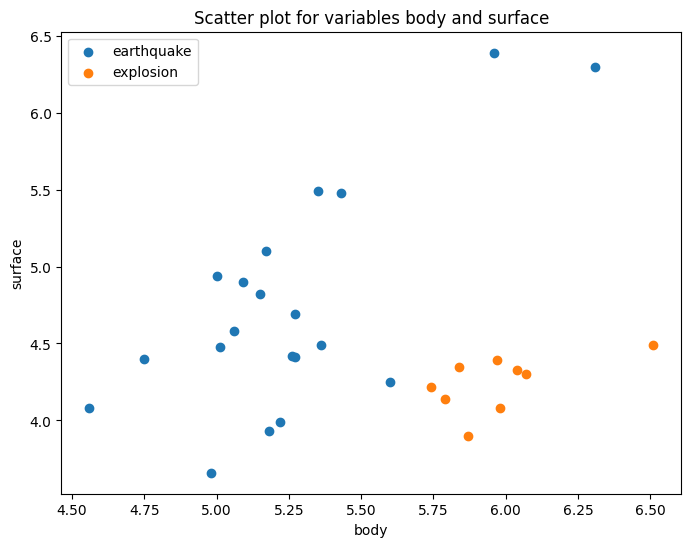

In [6]:
plt.figure(figsize=(8, 6))
plt.scatter(
    earthquake_df["body"][y_earthquake == "equake"], 
    earthquake_df["surface"][y_earthquake == "equake"],
    label="earthquake",   # label
)
plt.scatter(
    earthquake_df["body"][y_earthquake == "explosn"], 
    earthquake_df["surface"][y_earthquake == "explosn"],
    label="explosion"
)

plt.xlabel("body")
plt.ylabel("surface")
plt.legend()
plt.title("Scatter plot for variables body and surface")

Observation: classes are linearly separable.

In [7]:
y_earthquake_bin = (y_earthquake == "equake").astype(int)

#### **Logistic regression without penalty**

In [8]:
logistic_regression_no_reg = LogisticRegression(penalty=None)
logistic_regression_no_reg.fit(X_earthquake, y_earthquake_bin)

,penalty,None
,dual,False
,tol,0.0001
,C,1.0
,fit_intercept,True
,intercept_scaling,1
,class_weight,None
,random_state,None
,solver,'lbfgs'
,max_iter,100
,multi_class,'deprecated'


In [9]:
# estimated coefficients
print("Intercept: ", logistic_regression_no_reg.intercept_)
print("Coefficients: ", logistic_regression_no_reg.coef_)

Intercept:  [135.04765908]
Coefficients:  [[-111.91608035  117.54515973]]


In [ ]:
y_pred_prob_no_reg = logistic_regression_no_reg.predict_proba(X_earthquake)[:, 1]   # predict proba zwraca p-stwa dla wszystkich klas [:, 0] -> P(y=0|x), [:, 1] -> P(y=1|x)
y_pred_prob_no_reg

array([9.99623621e-01, 9.99999969e-01, 1.00000000e+00, 1.00000000e+00,
       1.00000000e+00, 1.00000000e+00, 1.00000000e+00, 1.00000000e+00,
       1.00000000e+00, 1.00000000e+00, 1.00000000e+00, 1.00000000e+00,
       9.99637043e-01, 9.99999998e-01, 1.00000000e+00, 1.00000000e+00,
       1.00000000e+00, 1.00000000e+00, 1.00000000e+00, 1.00000000e+00,
       1.32480690e-14, 3.86743432e-08, 7.30679033e-04, 3.74917668e-12,
       2.71494851e-28, 2.79186798e-29, 1.22488279e-05, 1.88851825e-24,
       1.35687571e-17])

In [ ]:
eps = 1e-15
y_pred_prob_no_reg = np.clip(y_pred_prob_no_reg, eps, 1-eps)   # jesli y_pred_prob_no_reg jest mniejsza niz 10^-15 ustawia 10^-15, a jesli jest wieksza od 1-10^-15 to ustawia 1-10^-15
y_pred_prob_no_reg

array([9.99623621e-01, 9.99999969e-01, 1.00000000e+00, 1.00000000e+00,
       1.00000000e+00, 1.00000000e+00, 1.00000000e+00, 1.00000000e+00,
       1.00000000e+00, 1.00000000e+00, 1.00000000e+00, 1.00000000e+00,
       9.99637043e-01, 9.99999998e-01, 1.00000000e+00, 1.00000000e+00,
       1.00000000e+00, 1.00000000e+00, 1.00000000e+00, 1.00000000e+00,
       1.32480690e-14, 3.86743432e-08, 7.30679033e-04, 3.74917668e-12,
       1.00000000e-15, 1.00000000e-15, 1.22488279e-05, 1.00000000e-15,
       1.00000000e-15])

In [12]:
# log-likelihood
log_likelihood_elements_no_reg = y_earthquake_bin * np.log(y_pred_prob_no_reg) + (1-y_earthquake_bin) * np.log(1-y_pred_prob_no_reg)

In [13]:
log_likelihood_no_reg = log_likelihood_elements_no_reg.sum()
log_likelihood_no_reg

-0.0014827399403201326

#### **Logistic regression with l2 regularization**

In [14]:
lambda_val = 2
logistic_regression_l2 = LogisticRegression(penalty="l2", C=1/lambda_val)
logistic_regression_l2.fit(X_earthquake, y_earthquake_bin)

,penalty,'l2'
,dual,False
,tol,0.0001
,C,0.5
,fit_intercept,True
,intercept_scaling,1
,class_weight,None
,random_state,None
,solver,'lbfgs'
,max_iter,100
,multi_class,'deprecated'


In [15]:
# estimated coefficients
print("Intercept: ", logistic_regression_l2.intercept_)
print("Coefficients: ", logistic_regression_l2.coef_)

Intercept:  [4.97970081]
Coefficients:  [[-1.43254456  0.82095835]]


In [16]:
# estimated probabilities
y_pred_prob_l2 = logistic_regression_l2.predict_proba(X_earthquake)[:, 1]
y_pred_prob_l2

array([0.60981253, 0.68686133, 0.75257297, 0.72856714, 0.84391606,
       0.74519594, 0.85325136, 0.85659972, 0.86088365, 0.81465503,
       0.74089342, 0.78253243, 0.70063772, 0.68512855, 0.81623051,
       0.84693288, 0.82622641, 0.85775989, 0.8667487 , 0.84551326,
       0.47050462, 0.50785359, 0.5460713 , 0.52099649, 0.44334481,
       0.34072584, 0.55511001, 0.4409258 , 0.45370206])

In [17]:
eps = 1e-15
y_pred_prob_l2 = np.clip(y_pred_prob_l2, eps, 1-eps)
y_pred_prob_l2

array([0.60981253, 0.68686133, 0.75257297, 0.72856714, 0.84391606,
       0.74519594, 0.85325136, 0.85659972, 0.86088365, 0.81465503,
       0.74089342, 0.78253243, 0.70063772, 0.68512855, 0.81623051,
       0.84693288, 0.82622641, 0.85775989, 0.8667487 , 0.84551326,
       0.47050462, 0.50785359, 0.5460713 , 0.52099649, 0.44334481,
       0.34072584, 0.55511001, 0.4409258 , 0.45370206])

In [18]:
# log-likelihood
log_likelihood_elements_l2 = y_earthquake_bin * np.log(y_pred_prob_l2) + (1 - y_earthquake_bin) * np.log(1 - y_pred_prob_l2)

In [19]:
log_likelihood_l2 = log_likelihood_elements_l2.sum()
log_likelihood_l2

-10.77569026896332

#### **Compare the two fits and explain what happens when the classes are linearly separable.**

Unregularized logistic regression:
- coefficients are very large
- predicted probabilities are extreme, very close to 1 or 0<br>

L2-regularized logistic regression:
- coefficients are much smaller
- predicted probabilities are less extreme 

#### **Why can the coefficients in the unregularized model become very large?**
When the classes are linearly separable, logistic regression without regularization does not have a finite maximum of likelihood function. The model can increase the coefficients indefinitely to make predicted probabilities closer to 0 and 1 for each class. This leads to very large coefficient values. Regularization prevents this behaviour by penalizing large weights.

#### **To the scatterplot, add the decision boundary for both models.**

1. Unregularized logistic regression

In [20]:
x_vals = np.linspace(X_earthquake["body"].min(), X_earthquake["body"].max(), 200)

b0_no_reg = logistic_regression_no_reg.intercept_[0]
b1_no_reg = logistic_regression_no_reg.coef_[0, 0]
b2_no_reg = logistic_regression_no_reg.coef_[0, 1]

# b_0 + b_1 * body + b_2 * surface = 0
y_vals_no_reg = (-b0_no_reg - b1_no_reg * x_vals) / b2_no_reg

2. L2-regularized logistic regression

In [21]:
b0_l2 = logistic_regression_l2.intercept_[0]
b1_l2 = logistic_regression_l2.coef_[0, 0]
b2_l2 = logistic_regression_l2.coef_[0, 1]

y_vals_l2 = (-b0_l2 - b1_l2 * x_vals) / b2_l2

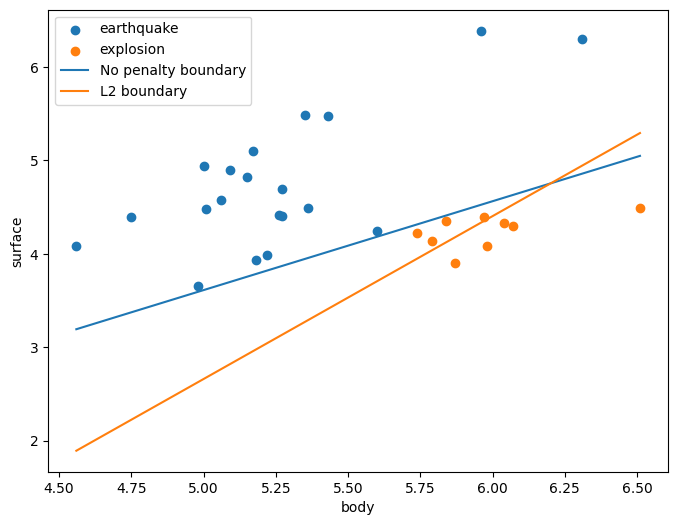

In [22]:
plt.figure(figsize=(8, 6))

plt.scatter(
    earthquake_df["body"][y_earthquake == "equake"], 
    earthquake_df["surface"][y_earthquake == "equake"],
    label="earthquake",
)

plt.scatter(
    earthquake_df["body"][y_earthquake == "explosn"], 
    earthquake_df["surface"][y_earthquake == "explosn"],
    label="explosion"
)

plt.plot(x_vals, y_vals_no_reg, label="No penalty boundary")
plt.plot(x_vals, y_vals_l2, label="L2 boundary")

plt.xlabel("body")
plt.ylabel("surface")
plt.legend()
plt.show()

## **Task 2**

In [23]:
from experiment import y_generation, experiment, mse_depending_on_n, compare_experiments

#### **First subtask**

In [24]:
n = 50
X = np.random.normal(loc=0, scale=1, size=(n, 5))

In [25]:
y = y_generation(X=X)

In [26]:
logistic_regression = LogisticRegression(penalty=None)
logistic_regression.fit(X, y)
print("Coefficients: ", logistic_regression.coef_[0])

Coefficients:  [1.27266718 1.01269463 1.40154157 1.04546886 1.75930585]


In [27]:
mse_est = experiment()

In [28]:
mse_est

41.9527239325749

#### **Second subtask**

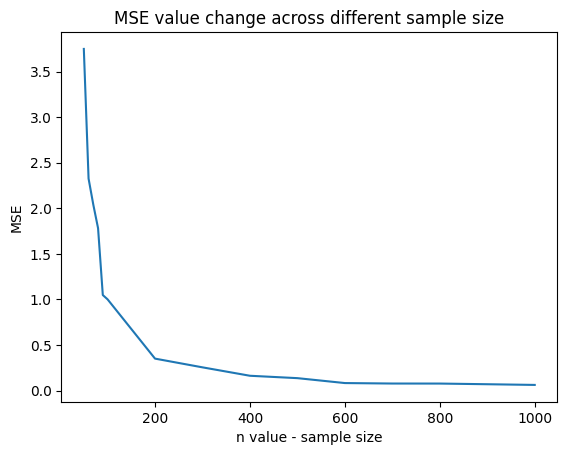

In [32]:
mse_depending_on_n(n_vals=[50, 60, 70, 80, 90, 100, 200, 300, 400, 500, 600, 700, 800, 900, 1000])

#### **Third subtask**

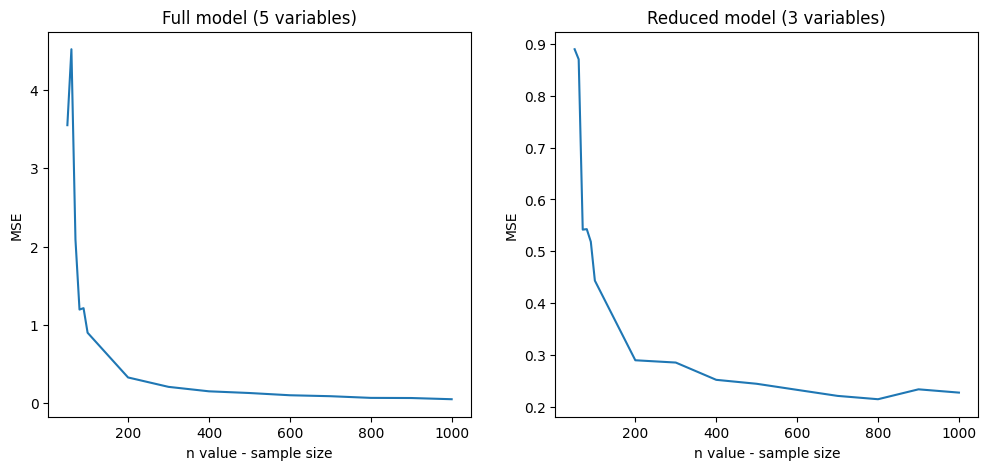

In [31]:
compare_experiments(n_vals=[50, 60, 70, 80, 90, 100, 200, 300, 400, 500, 600, 700, 800, 900, 1000])

For the model without ommiting variables MSE decreases very quickly with n. For big samples MSE is very close to 0.<br>
In the model trained on only three variables MSE is small from the start but it decreases more slowly and stabilizes at certain level value even for large sample sizes.